# Ablation Studies Summary Figure

A double-column figure summarizing all ablation studies for the main paper:
1. **Component Loss Weight** ($\lambda_{comp}$): Effect of varying the component caption loss weight
2. **Fine-tuning Strategy**: Full vs Text-only vs Image-only fine-tuning
3. **Model Architecture**: ViT-B/32 vs ViT-B/16 vs ViT-L/14
4. **Paraphrase Loss Weight** ($\lambda_{para}$): Effect of paraphrase regularization

In [13]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Add ablations path for utilities
sys.path.insert(0, str(Path('../ablations').resolve()))

from ablation_utils import (
    load_all_ablation_models,
    load_all_models_all_metrics,
    METRICS, METRIC_DISPLAY
)

# ICML 2024 formatting
import tueplots
from tueplots import figsizes, fontsizes
from tueplots.constants.color import palettes

# Colorblind-friendly palette
COLORBLIND_PALETTE = [f"#{c}" if not c.startswith("#") else c for c in palettes.paultol_bright]

plt.rcParams.update(figsizes.icml2024_full())
plt.rcParams.update(fontsizes.icml2024())
plt.rcParams.update({
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
})

# Output directory
Path('../paper_figures').mkdir(exist_ok=True)

In [15]:
# =============================================================================
# ABLATION CONFIGURATIONS
# =============================================================================

# 1. Component Loss Weight (λ_comp)
COMP_LAMBDA_MODELS = {
    "0.1": {
        "csv_path": "../evaluation/ablations/03-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.1_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_comp_lambda_0.1.csv",
        "is_baseline": False,
        "lambda_value": 0.1
    },
    "0.25": {
        "csv_path": "../evaluation/ablations/03-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.25_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_comp_lambda_0.25.csv",
        "is_baseline": False,
        "lambda_value": 0.25
    },
    "0.5": {
        "csv_path": "../evaluation/exp_csv/19-Dec_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.0_inplace1.0_swap1.0_csclip-negclip-hard-new_cleaned.csv",
        "is_baseline": True,
        "lambda_value": 0.5
    },
    "0.75": {
        "csv_path": "../evaluation/ablations/04-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.75_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_comp_lambda_0.75.csv",
        "is_baseline": False,
        "lambda_value": 0.75
    },
    "1.0": {
        "csv_path": "../evaluation/ablations/04-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc1.0_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_comp_lambda_1.0.csv",
        "is_baseline": False,
        "lambda_value": 1.0
    },
}

# 2. Fine-tuning Strategy
FINETUNING_MODELS = {
    "Full": {
        "csv_path": "../evaluation/exp_csv/19-Dec_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.0_inplace1.0_swap1.0_csclip-negclip-hard-new_cleaned.csv",
        "is_baseline": True,
    },
    "Text Only": {
        "csv_path": "../evaluation/ablations/15-Jan_ablation_freeze_image_ft_text.csv",
        "is_baseline": False,
    },
    "Image Only": {
        "csv_path": "../evaluation/ablations/15-Jan_ablation_freeze_text_ft_image.csv",
        "is_baseline": False,
    },
}

# 3. Model Architecture
ARCHITECTURE_MODELS = {
    "ViT-B/32": {
        "csv_path": "../evaluation/exp_csv/19-Dec_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.0_inplace1.0_swap1.0_csclip-negclip-hard-new_cleaned.csv",
        "is_baseline": True,
    },
    "ViT-B/16": {
        "csv_path": "../evaluation/ablations/15-Jan_ablation_model_vit_b16_openai.csv",
        "is_baseline": False,
    },
    "ViT-L/14": {
        "csv_path": "../evaluation/ablations/15-Jan_ablation_model_vit_l14_openai.csv",
        "is_baseline": False,
    },
}

# 4. Paraphrase Loss Weight (λ_para)
PARA_LAMBDA_MODELS = {
    "0": {
        "csv_path": "../evaluation/exp_csv/19-Dec_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.0_inplace1.0_swap1.0_csclip-negclip-hard-new_cleaned.csv",
        "is_baseline": True,
        "lambda_value": 0
    },
    "0.1": {
        "csv_path": "../evaluation/ablations/16-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_paraphrase_0.1.csv",
        "is_baseline": False,
        "lambda_value": 0.1
    },
    "0.2": {
        "csv_path": "../evaluation/ablations/16-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_paraphrase_0.2.csv",
        "is_baseline": False,
        "lambda_value": 0.2
    },
    "0.3": {
        "csv_path": "../evaluation/ablations/17-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_paraphrase_0.3.csv",
        "is_baseline": False,
        "lambda_value": 0.3
    },
    "0.5": {
        "csv_path": "../evaluation/ablations/17-Jan_coco_with_components_negatives_structured_rel1.0_either_max2_lf1.0_lc0.5_negclip_hard_lr5ee-6_wd1e-2_neg_rel0.2_inplace1.0_swap1.0_ablation_paraphrase_0.5.csv",
        "is_baseline": False,
        "lambda_value": 0.5
    },
}

PRIMARY_METRIC = "text_contrastive_accuracy"
CHECKPOINT_STEP = None

In [16]:
# =============================================================================
# LOAD ALL ABLATION DATA
# =============================================================================

print("Loading Component Lambda ablation...")
comp_df = load_all_models_all_metrics(COMP_LAMBDA_MODELS, METRICS, CHECKPOINT_STEP)
comp_summary = comp_df[['I2T', 'T2I', 'Group']].copy()
comp_summary['Average'] = comp_summary.mean(axis=1)

print("\nLoading Fine-tuning ablation...")
ft_df = load_all_models_all_metrics(FINETUNING_MODELS, METRICS, CHECKPOINT_STEP)
ft_summary = ft_df[['I2T', 'T2I', 'Group']].copy()
ft_summary['Average'] = ft_summary.mean(axis=1)

print("\nLoading Architecture ablation...")
arch_df = load_all_models_all_metrics(ARCHITECTURE_MODELS, METRICS, CHECKPOINT_STEP)
arch_summary = arch_df[['I2T', 'T2I', 'Group']].copy()
arch_summary['Average'] = arch_summary.mean(axis=1)

print("\nLoading Paraphrase Lambda ablation...")
para_df = load_all_models_all_metrics(PARA_LAMBDA_MODELS, METRICS, CHECKPOINT_STEP)
para_summary = para_df[['I2T', 'T2I', 'Group']].copy()
para_summary['Average'] = para_summary.mean(axis=1)

print("\n" + "="*60)
print("DATA LOADING COMPLETE")
print("="*60)

Loading Component Lambda ablation...
Loading 0.1...
[apply_mappings] Dropped 8 original rows replaced by aliased metrics
  Loaded metrics: ['I2T', 'T2I', 'Group']
Loading 0.25...
[apply_mappings] Dropped 8 original rows replaced by aliased metrics
  Loaded metrics: ['I2T', 'T2I', 'Group']
Loading 0.5...
[apply_mappings] Dropped 16 original rows replaced by aliased metrics
  Loaded metrics: ['I2T', 'T2I', 'Group']
Loading 0.75...
[apply_mappings] Dropped 8 original rows replaced by aliased metrics
  Loaded metrics: ['I2T', 'T2I', 'Group']
Loading 1.0...
[apply_mappings] Dropped 8 original rows replaced by aliased metrics
  Loaded metrics: ['I2T', 'T2I', 'Group']

Common datasets across all models (19): ['BLA', 'COCO-CF', 'COCO_Order', 'COLA', 'ColorFoil', 'ColorSwap', 'ControlledImages', 'Flickr30k_Order', 'MMVP', 'NegBench', 'SPEC', 'SugarCrepe', 'SugarCrepe++', 'VALSE', 'VG_Attribution', 'VG_Relation', 'VL_CheckList', 'VisMin', 'Winoground']

Loading Fine-tuning ablation...
Loading Fu

In [17]:
# =============================================================================
# DEFINE COLORS AND STYLES
# =============================================================================

# Metric colors (consistent across all plots)
METRIC_COLORS = {
    'I2T': COLORBLIND_PALETTE[0],      # Blue
    'T2I': COLORBLIND_PALETTE[1],      # Orange
    'Group': COLORBLIND_PALETTE[2],    # Green
    'Average': COLORBLIND_PALETTE[3],  # Purple/Pink
}

# Baseline marker style
BASELINE_COLOR = '#444444'

def get_baseline_idx(models_config):
    """Get index of baseline model."""
    for i, (name, cfg) in enumerate(models_config.items()):
        if cfg.get('is_baseline', False):
            return i
    return None

/tmp/ipykernel_1839994/3063563491.py:65: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


Saved: ../paper_figures/ablation_summary_2x2.pdf


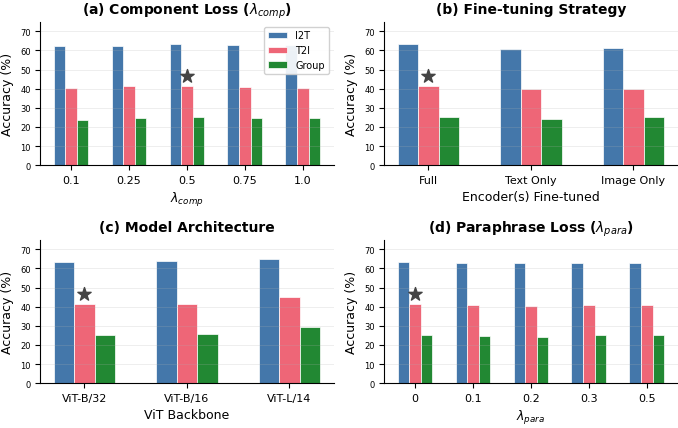

In [18]:
# =============================================================================
# CREATE 2x2 ABLATION SUMMARY FIGURE
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(7.0, 4.5))  # ICML double-column width

# Common settings
bar_width = 0.2
metrics_to_plot = ['I2T', 'T2I', 'Group']

def plot_grouped_bars(ax, summary_df, models_config, title, xlabel=None, show_legend=False):
    """Plot grouped bar chart for an ablation study."""
    n_models = len(summary_df)
    n_metrics = len(metrics_to_plot)
    x = np.arange(n_models)
    
    for i, metric in enumerate(metrics_to_plot):
        offset = (i - n_metrics/2 + 0.5) * bar_width
        values = summary_df[metric].values * 100
        bars = ax.bar(x + offset, values, bar_width,
                      label=metric, color=METRIC_COLORS[metric],
                      edgecolor='white', linewidth=0.5)
    
    # Mark baseline with star
    baseline_idx = get_baseline_idx(models_config)
    if baseline_idx is not None:
        ax.scatter([baseline_idx], [summary_df.iloc[baseline_idx]['Average'] * 100 + 3],
                   marker='*', s=100, color=BASELINE_COLOR, zorder=10)
    
    # Formatting
    ax.set_xticks(x)
    ax.set_xticklabels(summary_df.index, fontsize=8)
    ax.set_ylabel('Accuracy (%)', fontsize=9)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_ylim(0, 75)  # Consistent y-axis for comparison
    ax.grid(True, axis='y', alpha=0.3, linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    if show_legend:
        ax.legend(loc='upper right', fontsize=7, framealpha=0.9)

# (a) Component Loss Weight
plot_grouped_bars(axes[0, 0], comp_summary, COMP_LAMBDA_MODELS,
                  r'(a) Component Loss ($\lambda_{comp}$)',
                  xlabel=r'$\lambda_{comp}$', show_legend=True)

# (b) Fine-tuning Strategy  
plot_grouped_bars(axes[0, 1], ft_summary, FINETUNING_MODELS,
                  '(b) Fine-tuning Strategy',
                  xlabel='Encoder(s) Fine-tuned')

# (c) Model Architecture
plot_grouped_bars(axes[1, 0], arch_summary, ARCHITECTURE_MODELS,
                  '(c) Model Architecture',
                  xlabel='ViT Backbone')

# (d) Paraphrase Loss Weight
plot_grouped_bars(axes[1, 1], para_summary, PARA_LAMBDA_MODELS,
                  r'(d) Paraphrase Loss ($\lambda_{para}$)',
                  xlabel=r'$\lambda_{para}$')

plt.tight_layout()

# Save figure
save_path = '../paper_figures/ablation_summary_2x2.pdf'
plt.savefig(save_path, bbox_inches='tight', dpi=300)
print(f"Saved: {save_path}")

plt.show()

/tmp/ipykernel_1839994/1446165831.py:42: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


Saved: ../paper_figures/ablation_lambda_lines.pdf


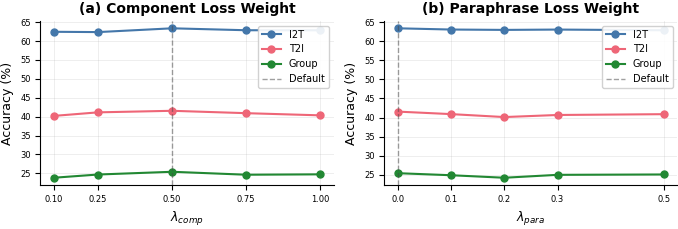

In [19]:
# =============================================================================
# ALTERNATIVE: LINE PLOTS FOR LAMBDA ABLATIONS (showing trends)
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.5))

def plot_lambda_line(ax, summary_df, models_config, param_key, title, xlabel):
    """Plot line chart showing performance vs lambda value."""
    # Extract lambda values
    lambda_vals = [models_config[name].get(param_key, float(name.replace('λ_comp=', '').replace('λ_para=', ''))) 
                   for name in summary_df.index]
    
    for metric in ['I2T', 'T2I', 'Group']:
        values = summary_df[metric].values * 100
        ax.plot(lambda_vals, values, 'o-', label=metric,
                color=METRIC_COLORS[metric], linewidth=1.5, markersize=5)
    
    # Mark baseline
    baseline_idx = get_baseline_idx(models_config)
    if baseline_idx is not None:
        baseline_lambda = lambda_vals[baseline_idx]
        ax.axvline(x=baseline_lambda, color=BASELINE_COLOR, linestyle='--', 
                   alpha=0.5, linewidth=1, label='Default')
    
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel('Accuracy (%)', fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xticks(lambda_vals)
    ax.grid(True, alpha=0.3, linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(loc='best', fontsize=7, framealpha=0.9)

# (a) Component Lambda
plot_lambda_line(axes[0], comp_summary, COMP_LAMBDA_MODELS, 'lambda_value',
                 r'(a) Component Loss Weight', r'$\lambda_{comp}$')

# (b) Paraphrase Lambda
plot_lambda_line(axes[1], para_summary, PARA_LAMBDA_MODELS, 'lambda_value',
                 r'(b) Paraphrase Loss Weight', r'$\lambda_{para}$')

plt.tight_layout()

save_path = '../paper_figures/ablation_lambda_lines.pdf'
plt.savefig(save_path, bbox_inches='tight', dpi=300)
print(f"Saved: {save_path}")

plt.show()

/tmp/ipykernel_1839994/4028076168.py:37: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


Saved: ../paper_figures/ablation_summary_compact.pdf


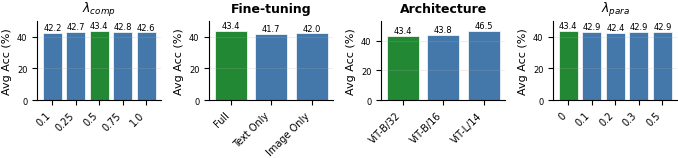

In [20]:
# =============================================================================
# COMPACT VERSION: Single Row with Average Only
# =============================================================================

fig, axes = plt.subplots(1, 4, figsize=(7.0, 1.8))
def plot_compact_bar(ax, summary_df, models_config, title, xlabel=None):
    """Plot compact bar chart showing just the Average metric."""
    x = np.arange(len(summary_df))
    values = summary_df['Average'].values * 100
    
    # Color bars - highlight baseline
    baseline_idx = get_baseline_idx(models_config)
    colors = [COLORBLIND_PALETTE[2] if i == baseline_idx else COLORBLIND_PALETTE[0] 
              for i in range(len(summary_df))]
    
    bars = ax.bar(x, values, color=colors, edgecolor='white', linewidth=0.5)
    
    # Add value labels on bars
    for i, (bar, val) in enumerate(zip(bars, values)):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}', ha='center', va='bottom', fontsize=6)
    
    ax.set_xticks(x)
    ax.set_xticklabels(summary_df.index, fontsize=7, rotation=45, ha='right')
    ax.set_ylabel('Avg Acc (%)', fontsize=8)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_ylim(0, max(values) * 1.15)
    ax.grid(True, axis='y', alpha=0.3, linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plot_compact_bar(axes[0], comp_summary, COMP_LAMBDA_MODELS, r'$\lambda_{comp}$')
plot_compact_bar(axes[1], ft_summary, FINETUNING_MODELS, 'Fine-tuning')
plot_compact_bar(axes[2], arch_summary, ARCHITECTURE_MODELS, 'Architecture')
plot_compact_bar(axes[3], para_summary, PARA_LAMBDA_MODELS, r'$\lambda_{para}$')

plt.tight_layout()

save_path = '../paper_figures/ablation_summary_compact.pdf'
plt.savefig(save_path, bbox_inches='tight', dpi=300)
print(f"Saved: {save_path}")

plt.show()

Saved: ../paper_figures/ablation_summary_creative.pdf


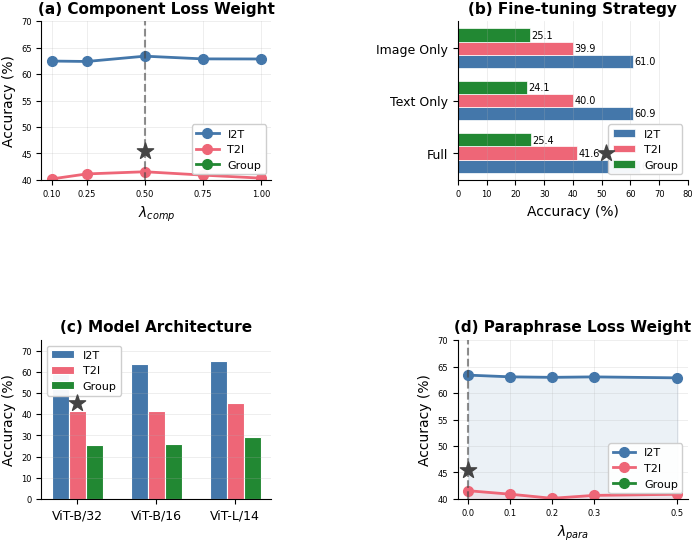

In [22]:
# =============================================================================
# CREATIVE VISUALIZATIONS: Different styles for each ablation
# =============================================================================

fig = plt.figure(figsize=(7.0, 5.5))

# Create a 2x2 grid with different plot types for variety
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.3)

# -----------------------------------------------------------------------------
# (a) Component Lambda: LINE PLOT (continuous hyperparameter)
# -----------------------------------------------------------------------------
ax1 = fig.add_subplot(gs[0, 0])

lambda_vals = [COMP_LAMBDA_MODELS[name]['lambda_value'] for name in comp_summary.index]

for metric in ['I2T', 'T2I', 'Group']:
    values = comp_summary[metric].values * 100
    ax1.plot(lambda_vals, values, 'o-', label=metric,
             color=METRIC_COLORS[metric], linewidth=2, markersize=7)

# Mark baseline
baseline_idx = get_baseline_idx(COMP_LAMBDA_MODELS)
baseline_lambda = lambda_vals[baseline_idx]
ax1.axvline(x=baseline_lambda, color=BASELINE_COLOR, linestyle='--', alpha=0.6, linewidth=1.5)
ax1.scatter([baseline_lambda], [comp_summary.iloc[baseline_idx]['Average'] * 100 + 2],
            marker='*', s=150, color=BASELINE_COLOR, zorder=10)

ax1.set_xlabel(r'$\lambda_{comp}$', fontsize=10)
ax1.set_ylabel('Accuracy (%)', fontsize=10)
ax1.set_title(r'(a) Component Loss Weight', fontsize=11, fontweight='bold')
ax1.set_xticks(lambda_vals)
ax1.legend(loc='lower right', fontsize=8, framealpha=0.95)
ax1.grid(True, alpha=0.3, linewidth=0.5)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_ylim(40, 70)

# -----------------------------------------------------------------------------
# (b) Fine-tuning Strategy: HORIZONTAL GROUPED BARS (categorical)
# -----------------------------------------------------------------------------
ax2 = fig.add_subplot(gs[0, 1])

y = np.arange(len(ft_summary))
bar_height = 0.25
metrics = ['I2T', 'T2I', 'Group']

for i, metric in enumerate(metrics):
    offset = (i - len(metrics)/2 + 0.5) * bar_height
    values = ft_summary[metric].values * 100
    bars = ax2.barh(y + offset, values, bar_height, label=metric,
                    color=METRIC_COLORS[metric], edgecolor='white', linewidth=0.5)
    
    # Add value labels
    for bar, val in zip(bars, values):
        ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}', va='center', ha='left', fontsize=7)

# Mark baseline
baseline_idx = get_baseline_idx(FINETUNING_MODELS)
ax2.scatter([ft_summary.iloc[baseline_idx]['Average'] * 100 + 8], [baseline_idx],
            marker='*', s=150, color=BASELINE_COLOR, zorder=10)

ax2.set_yticks(y)
ax2.set_yticklabels(ft_summary.index, fontsize=9)
ax2.set_xlabel('Accuracy (%)', fontsize=10)
ax2.set_title('(b) Fine-tuning Strategy', fontsize=11, fontweight='bold')
ax2.set_xlim(0, 80)
ax2.legend(loc='lower right', fontsize=8, framealpha=0.95)
ax2.grid(True, axis='x', alpha=0.3, linewidth=0.5)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# -----------------------------------------------------------------------------
# (c) Model Architecture: STACKED AREA-STYLE with markers
# -----------------------------------------------------------------------------
ax3 = fig.add_subplot(gs[1, 0])

x = np.arange(len(arch_summary))
width = 0.65

# Create grouped bars with pattern fills for distinction
for i, metric in enumerate(metrics):
    offset = (i - len(metrics)/2 + 0.5) * (width / len(metrics))
    values = arch_summary[metric].values * 100
    bars = ax3.bar(x + offset, values, width / len(metrics), label=metric,
                   color=METRIC_COLORS[metric], edgecolor='white', linewidth=0.8)

# Mark baseline
baseline_idx = get_baseline_idx(ARCHITECTURE_MODELS)
ax3.scatter([baseline_idx], [arch_summary.iloc[baseline_idx]['Average'] * 100 + 2],
            marker='*', s=150, color=BASELINE_COLOR, zorder=10)

ax3.set_xticks(x)
ax3.set_xticklabels(arch_summary.index, fontsize=9)
ax3.set_ylabel('Accuracy (%)', fontsize=10)
ax3.set_title('(c) Model Architecture', fontsize=11, fontweight='bold')
ax3.set_ylim(0, 75)
ax3.legend(loc='upper left', fontsize=8, framealpha=0.95)
ax3.grid(True, axis='y', alpha=0.3, linewidth=0.5)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

# -----------------------------------------------------------------------------
# (d) Paraphrase Lambda: LINE PLOT with filled area
# -----------------------------------------------------------------------------
ax4 = fig.add_subplot(gs[1, 1])

lambda_vals_para = [PARA_LAMBDA_MODELS[name]['lambda_value'] for name in para_summary.index]

# Plot lines with filled area underneath
for metric in ['I2T', 'T2I', 'Group']:
    values = para_summary[metric].values * 100
    ax4.plot(lambda_vals_para, values, 'o-', label=metric,
             color=METRIC_COLORS[metric], linewidth=2, markersize=7)
    ax4.fill_between(lambda_vals_para, values, alpha=0.1, color=METRIC_COLORS[metric])

# Mark baseline
baseline_idx = get_baseline_idx(PARA_LAMBDA_MODELS)
baseline_lambda = lambda_vals_para[baseline_idx]
ax4.axvline(x=baseline_lambda, color=BASELINE_COLOR, linestyle='--', alpha=0.6, linewidth=1.5)
ax4.scatter([baseline_lambda], [para_summary.iloc[baseline_idx]['Average'] * 100 + 2],
            marker='*', s=150, color=BASELINE_COLOR, zorder=10)

ax4.set_xlabel(r'$\lambda_{para}$', fontsize=10)
ax4.set_ylabel('Accuracy (%)', fontsize=10)
ax4.set_title(r'(d) Paraphrase Loss Weight', fontsize=11, fontweight='bold')
ax4.set_xticks(lambda_vals_para)
ax4.legend(loc='lower right', fontsize=8, framealpha=0.95)
ax4.grid(True, alpha=0.3, linewidth=0.5)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.set_ylim(40, 70)

# Save
save_path = '../paper_figures/ablation_summary_creative.pdf'
plt.savefig(save_path, bbox_inches='tight', dpi=300)
print(f"Saved: {save_path}")

plt.show()

Saved: ../paper_figures/ablation_delta_heatmap.pdf


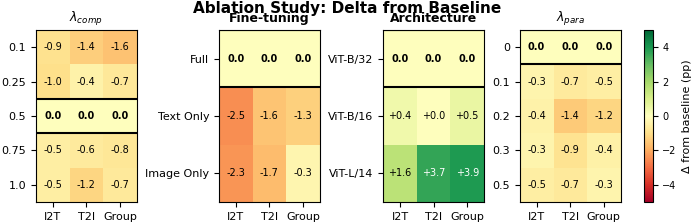

In [23]:
# =============================================================================
# HEATMAP-STYLE DELTA VISUALIZATION
# =============================================================================

fig, axes = plt.subplots(1, 4, figsize=(7.0, 2.2))

def plot_delta_heatmap(ax, summary_df, models_config, title):
    """Plot a heatmap showing delta from baseline for each metric."""
    baseline_name = [n for n, cfg in models_config.items() if cfg.get('is_baseline', False)]
    baseline_name = baseline_name[0] if baseline_name else summary_df.index[0]
    
    # Compute deltas
    baseline_scores = summary_df.loc[baseline_name]
    deltas = (summary_df - baseline_scores) * 100  # percentage points
    
    # Only plot I2T, T2I, Group
    plot_cols = ['I2T', 'T2I', 'Group']
    delta_matrix = deltas[plot_cols].values
    
    # Create heatmap
    im = ax.imshow(delta_matrix, cmap='RdYlGn', aspect='auto', 
                   vmin=-5, vmax=5)
    
    # Add text annotations
    for i in range(len(summary_df)):
        for j in range(len(plot_cols)):
            val = delta_matrix[i, j]
            text_color = 'white' if abs(val) > 3 else 'black'
            sign = '+' if val > 0 else ''
            ax.text(j, i, f'{sign}{val:.1f}', ha='center', va='center',
                    fontsize=7, color=text_color, fontweight='bold' if i == list(summary_df.index).index(baseline_name) else 'normal')
    
    # Highlight baseline row
    baseline_idx = list(summary_df.index).index(baseline_name)
    ax.axhline(y=baseline_idx - 0.5, color='black', linewidth=1.5)
    ax.axhline(y=baseline_idx + 0.5, color='black', linewidth=1.5)
    
    ax.set_xticks(np.arange(len(plot_cols)))
    ax.set_xticklabels(plot_cols, fontsize=8)
    ax.set_yticks(np.arange(len(summary_df)))
    ax.set_yticklabels(summary_df.index, fontsize=8)
    ax.set_title(title, fontsize=9, fontweight='bold')
    
    return im

plot_delta_heatmap(axes[0], comp_summary, COMP_LAMBDA_MODELS, r'$\lambda_{comp}$')
plot_delta_heatmap(axes[1], ft_summary, FINETUNING_MODELS, 'Fine-tuning')
plot_delta_heatmap(axes[2], arch_summary, ARCHITECTURE_MODELS, 'Architecture')
im = plot_delta_heatmap(axes[3], para_summary, PARA_LAMBDA_MODELS, r'$\lambda_{para}$')

# Add colorbar
cbar = fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)
cbar.set_label('Δ from baseline (pp)', fontsize=8)
cbar.ax.tick_params(labelsize=7)

plt.suptitle('Ablation Study: Delta from Baseline', fontsize=11, fontweight='bold', y=1.02)

save_path = '../paper_figures/ablation_delta_heatmap.pdf'
plt.savefig(save_path, bbox_inches='tight', dpi=300)
print(f"Saved: {save_path}")

plt.show()

/tmp/ipykernel_1839994/245789732.py:69: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


Saved: ../paper_figures/ablation_metric_centric.pdf


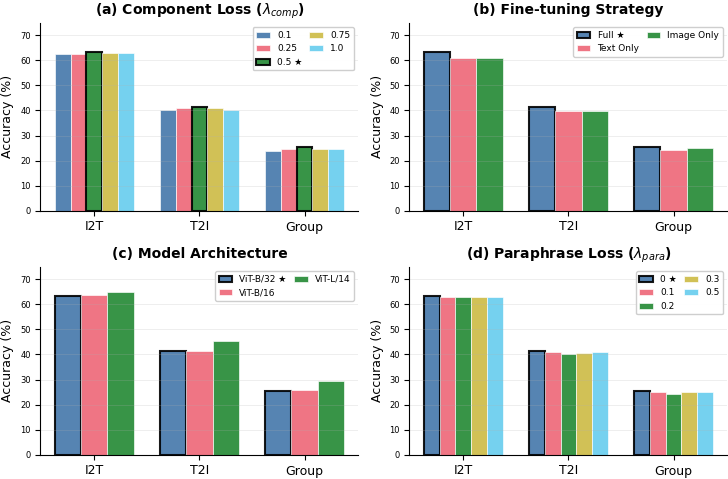

In [24]:
# =============================================================================
# METRIC-CENTRIC GROUPED BARS: X-axis = Metrics, Bars = Ablation Settings
# Star (★) in legend labels marks the baseline/default setting
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(7.5, 5.0))

def plot_metric_centric_bars(ax, summary_df, models_config, title, show_legend=False):
    """
    Plot grouped bars where X-axis is metrics (I2T, T2I, Group) 
    and different bars represent different ablation settings.
    Baseline model is indicated with ★ in the legend label.
    """
    metrics = ['I2T', 'T2I', 'Group']
    n_metrics = len(metrics)
    n_models = len(summary_df)
    
    x = np.arange(n_metrics)
    width = 0.75 / n_models  # Divide bar space among models
    
    # Color palette - baseline gets emphasized color
    colors = [COLORBLIND_PALETTE[i % len(COLORBLIND_PALETTE)] for i in range(n_models)]
    
    for i, (name, cfg) in enumerate(models_config.items()):
        offset = (i - n_models/2 + 0.5) * width
        values = [summary_df.loc[name, m] * 100 for m in metrics]
        
        # Add star to baseline label
        is_baseline = cfg.get('is_baseline', False)
        display_label = f'{name} ★' if is_baseline else name
        
        # Baseline gets thicker edge
        edgecolor = 'black' if is_baseline else 'white'
        linewidth = 1.5 if is_baseline else 0.5
        
        bars = ax.bar(x + offset, values, width, label=display_label,
                      color=colors[i], edgecolor=edgecolor, linewidth=linewidth, alpha=0.9)
    
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, fontsize=9)
    ax.set_ylabel('Accuracy (%)', fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_ylim(0, 75)
    ax.grid(True, axis='y', alpha=0.3, linewidth=0.5, zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    if show_legend:
        # Legend with star marking baseline
        leg = ax.legend(loc='upper right', fontsize=6.5, framealpha=0.95, 
                        ncol=min(2, n_models), handlelength=1.5, columnspacing=0.8)

# (a) Component Lambda
plot_metric_centric_bars(axes[0, 0], comp_summary, COMP_LAMBDA_MODELS,
                         r'(a) Component Loss ($\lambda_{comp}$)', show_legend=True)

# (b) Fine-tuning Strategy
plot_metric_centric_bars(axes[0, 1], ft_summary, FINETUNING_MODELS,
                         '(b) Fine-tuning Strategy', show_legend=True)

# (c) Model Architecture
plot_metric_centric_bars(axes[1, 0], arch_summary, ARCHITECTURE_MODELS,
                         '(c) Model Architecture', show_legend=True)

# (d) Paraphrase Lambda
plot_metric_centric_bars(axes[1, 1], para_summary, PARA_LAMBDA_MODELS,
                         r'(d) Paraphrase Loss ($\lambda_{para}$)', show_legend=True)

plt.tight_layout()

save_path = '../paper_figures/ablation_metric_centric.pdf'
plt.savefig(save_path, bbox_inches='tight', dpi=300)
print(f"Saved: {save_path}")

plt.show()

In [25]:
# =============================================================================
# DELTA TABLE: Show deltas from baseline for each ablation
# =============================================================================

def compute_deltas_from_baseline(summary_df, models_config):
    """Compute deltas from baseline model."""
    baseline_name = [name for name, cfg in models_config.items() if cfg.get('is_baseline', False)]
    if not baseline_name:
        return summary_df * 100  # No baseline, return raw values
    baseline_name = baseline_name[0]
    baseline_scores = summary_df.loc[baseline_name]
    deltas = (summary_df - baseline_scores) * 100  # Convert to percentage points
    return deltas

print("="*60)
print("DELTA FROM BASELINE (percentage points)")
print("="*60)

print("\n--- Component Lambda ---")
display(compute_deltas_from_baseline(comp_summary, COMP_LAMBDA_MODELS).round(2))

print("\n--- Fine-tuning Strategy ---")
display(compute_deltas_from_baseline(ft_summary, FINETUNING_MODELS).round(2))

print("\n--- Model Architecture ---")
display(compute_deltas_from_baseline(arch_summary, ARCHITECTURE_MODELS).round(2))

print("\n--- Paraphrase Lambda ---")
display(compute_deltas_from_baseline(para_summary, PARA_LAMBDA_MODELS).round(2))

DELTA FROM BASELINE (percentage points)

--- Component Lambda ---


,I2T,T2I,Group,Average
Model,,,,
0.1,-0.92,-1.35,-1.58,-1.29
0.25,-1.00,-0.41,-0.73,-0.71
0.5,0.00,0.00,0.00,0.00
0.75,-0.51,-0.63,-0.78,-0.64
1.0,-0.53,-1.20,-0.68,-0.80



--- Fine-tuning Strategy ---


,I2T,T2I,Group,Average
Model,,,,
Full,0.00,0.00,0.00,0.00
Text Only,-2.49,-1.56,-1.32,-1.79
Image Only,-2.35,-1.68,-0.30,-1.44



--- Model Architecture ---


,I2T,T2I,Group,Average
Model,,,,
ViT-B/32,0.00,0.00,0.00,0.00
ViT-B/16,0.36,0.03,0.53,0.31
ViT-L/14,1.57,3.66,3.92,3.05



--- Paraphrase Lambda ---


,I2T,T2I,Group,Average
Model,,,,
0,0.00,0.00,0.00,0.00
0.1,-0.32,-0.66,-0.54,-0.50
0.2,-0.42,-1.43,-1.20,-1.01
0.3,-0.33,-0.88,-0.43,-0.55
0.5,-0.51,-0.67,-0.33,-0.51


In [26]:
# =============================================================================
# SUMMARY TABLE (for LaTeX)
# =============================================================================

def make_summary_latex():
    """Generate a compact LaTeX summary table of all ablations."""
    lines = []
    lines.append(r"\begin{table}[t]")
    lines.append(r"  \centering")
    lines.append(r"  \small")
    lines.append(r"  \caption{Ablation study summary. Best configuration in \textbf{bold}, default in \underline{underline}. $\Delta$ shows change from default.}")
    lines.append(r"  \label{tab:ablation_summary}")
    lines.append(r"  \begin{tabular}{llcccc}")
    lines.append(r"    \toprule")
    lines.append(r"    Ablation & Setting & I2T & T2I & Group & Avg \\")
    lines.append(r"    \midrule")
    
    def add_ablation_rows(name, summary_df, models_config):
        rows = []
        baseline_name = [n for n, cfg in models_config.items() if cfg.get('is_baseline', False)]
        baseline_name = baseline_name[0] if baseline_name else None
        
        best_per_col = {col: summary_df[col].idxmax() for col in ['I2T', 'T2I', 'Group', 'Average']}
        
        for i, model in enumerate(summary_df.index):
            row = []
            if i == 0:
                row.append(f"    {name}")
            else:
                row.append("    ")
            
            row.append(model.replace('_', r'\_'))
            
            for col in ['I2T', 'T2I', 'Group', 'Average']:
                val = f"{summary_df.loc[model, col] * 100:.1f}"
                if model == best_per_col[col]:
                    val = r"\textbf{" + val + "}"
                if model == baseline_name:
                    val = r"\underline{" + val + "}"
                row.append(val)
            
            rows.append(" & ".join(row) + r" \\")
        
        return rows
    
    lines.extend(add_ablation_rows(r"$\lambda_{comp}$", comp_summary, COMP_LAMBDA_MODELS))
    lines.append(r"    \midrule")
    lines.extend(add_ablation_rows("Fine-tuning", ft_summary, FINETUNING_MODELS))
    lines.append(r"    \midrule")
    lines.extend(add_ablation_rows("Architecture", arch_summary, ARCHITECTURE_MODELS))
    lines.append(r"    \midrule")
    lines.extend(add_ablation_rows(r"$\lambda_{para}$", para_summary, PARA_LAMBDA_MODELS))
    
    lines.append(r"    \bottomrule")
    lines.append(r"  \end{tabular}")
    lines.append(r"\end{table}")
    
    return "\n".join(lines)

print("="*60)
print("LATEX TABLE")
print("="*60)
print(make_summary_latex())

LATEX TABLE
\begin{table}[t]
  \centering
  \small
  \caption{Ablation study summary. Best configuration in \textbf{bold}, default in \underline{underline}. $\Delta$ shows change from default.}
  \label{tab:ablation_summary}
  \begin{tabular}{llcccc}
    \toprule
    Ablation & Setting & I2T & T2I & Group & Avg \\
    \midrule
    $\lambda_{comp}$ & 0.1 & 62.5 & 40.2 & 23.8 & 42.2 \\
     & 0.25 & 62.4 & 41.1 & 24.7 & 42.7 \\
     & 0.5 & \underline{\textbf{63.4}} & \underline{\textbf{41.6}} & \underline{\textbf{25.4}} & \underline{\textbf{43.4}} \\
     & 0.75 & 62.9 & 40.9 & 24.6 & 42.8 \\
     & 1.0 & 62.9 & 40.3 & 24.7 & 42.6 \\
    \midrule
    Fine-tuning & Full & \underline{\textbf{63.4}} & \underline{\textbf{41.6}} & \underline{\textbf{25.4}} & \underline{\textbf{43.4}} \\
     & Text Only & 60.9 & 40.0 & 24.1 & 41.7 \\
     & Image Only & 61.0 & 39.9 & 25.1 & 42.0 \\
    \midrule
    Architecture & ViT-B/32 & \underline{63.4} & \underline{41.6} & \underline{25.4} & \underline{

In [12]:
# =============================================================================
# KEY FINDINGS SUMMARY
# =============================================================================

print("="*60)
print("KEY FINDINGS")
print("="*60)

def summarize_ablation(name, summary_df, models_config):
    avg_scores = summary_df['Average'] * 100
    best_model = avg_scores.idxmax()
    best_score = avg_scores.max()
    
    baseline_name = [n for n, cfg in models_config.items() if cfg.get('is_baseline', False)]
    baseline_name = baseline_name[0] if baseline_name else None
    baseline_score = avg_scores[baseline_name] if baseline_name else None
    
    print(f"\n{name}:")
    print(f"  Best: {best_model} ({best_score:.1f}%)")
    if baseline_name and baseline_score:
        delta = best_score - baseline_score
        print(f"  Default: {baseline_name} ({baseline_score:.1f}%)")
        if delta > 0:
            print(f"  Improvement: +{delta:.2f}pp over default")
        elif delta < 0:
            print(f"  Default is best (others are {abs(delta):.2f}pp worse)")
        else:
            print(f"  Default is optimal")

summarize_ablation("Component Loss Weight", comp_summary, COMP_LAMBDA_MODELS)
summarize_ablation("Fine-tuning Strategy", ft_summary, FINETUNING_MODELS)
summarize_ablation("Model Architecture", arch_summary, ARCHITECTURE_MODELS)
summarize_ablation("Paraphrase Loss Weight", para_summary, PARA_LAMBDA_MODELS)

KEY FINDINGS

Component Loss Weight:
  Best: 0.5 (43.4%)
  Default: 0.5 (43.4%)
  Default is optimal

Fine-tuning Strategy:
  Best: Full (43.4%)
  Default: Full (43.4%)
  Default is optimal

Model Architecture:
  Best: ViT-L/14 (46.5%)
  Default: ViT-B/32 (43.4%)
  Improvement: +3.05pp over default

Paraphrase Loss Weight:
  Best: 0 (43.4%)
  Default: 0 (43.4%)
  Default is optimal
